### PACKAGES, IMPORTS, AND CONSTANTS


In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns #for the confusion matrix visualization

# to include packages in packages folder
import sys
from PIL import Image
from PIL.ExifTags import TAGS
import io
sys.path.append('packages')

# from depth_anything_v2.dpt import DepthAnythingV2
from depth_anything_v2_metric.dpt import DepthAnythingV2
from ultralytics import YOLO # for YOLO11n Seg

# for the math geometry stuffs in feature extraction
from scipy.spatial import ConvexHull

# For reading folder in batch feature extraction
import os
from tqdm import tqdm

# Machine learning stuffs
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit #Gridsearch for hyperparameter tuning, GroupShuffleSpliy for training by mango id
from sklearn.metrics import r2_score, mean_absolute_error, classification_report, confusion_matrix
import joblib


xFormers not available
xFormers not available


In [2]:
# CONSTANTS
TRAIN_IMAGE_DIR = 'images/train'
MANGO_X_FEATURES_PATH = 'labels/train/mango_x_features_aruco.csv' # Calibrated with ArUco
MANGO_Y_FEATURES_PATH = 'labels/train/mango_y_features.csv'

# Camera intrinsic parameters (fx, fy, cx, cy). These allow us to project 2D pixels into 3D metric space.
INTRINSICS = (2123, 2123, 1500, 2000)


### LOAD MODELS: SEGMENTATION AND DEPTH MODEL

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'
dataset = 'hypersim' # 'hypersim' for indoor model, 'vkitti' for outdoor model
max_depth = 5  # 20 for indoor model, 80 for outdoor model

# Load Models:
# seg_model = YOLO("models/YoloV11n/runs/segment/train6/weights/best.pt")
# seg_model = YOLO("models/YoloV11n/runs/segment/mango_seg_v113/weights/best.pt")
seg_model = YOLO("models/YoloV11n/runs/segment/mango_seg_v1-4/weights/best.pt")
depth_model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
depth_model.load_state_dict(torch.load(f'models/DepthAnythingV2/depth_anything_v2_metric_{dataset}_{encoder}.pth', map_location='cpu'))
depth_model = depth_model.to(DEVICE).eval()


### FEATURE EXTRACTION


#### SINGLE


In [4]:
def extract_mango_features(image_path, intrinsics, seg_model, depth_model, showGraph, showRes):
    """
    Extracts 3D morphological and physiological features from a single mango image,
    calibrated with an ArUco 6x6 marker (ID 0) as a reference object.
    """
    import cv2.aruco as aruco
    
    raw_img_bgr = cv2.imread(image_path)
    if raw_img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return None
        
    raw_img_rgb = cv2.cvtColor(raw_img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = raw_img_bgr.shape
    fx, fy, cx, cy = intrinsics
    f = (fx + fy) / 2.0

    # 1. Robust ArUco marker detection (incorporating flips)
    dictionary = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
    parameters = aruco.DetectorParameters()
    detector = aruco.ArucoDetector(dictionary, parameters)
    
    filename = os.path.basename(image_path)
    if '_hor' in filename:
        flip_type = 'horizontal'
        img_flipped = cv2.flip(raw_img_bgr, 1)
    elif '_ver' in filename:
        flip_type = 'vertical'
        img_flipped = cv2.flip(raw_img_bgr, 0)
    else:
        flip_type = 'none'
        img_flipped = raw_img_bgr
        
    corners, ids, rejected = detector.detectMarkers(img_flipped)
    
    if ids is None or 0 not in ids:
        # Fallback: check all combinations
        found_fallback = False
        for ft, code in [('none', None), ('horizontal', 1), ('vertical', 0), ('both', -1)]:
            if ft == flip_type:
                continue
            img_f = raw_img_bgr if code is None else cv2.flip(raw_img_bgr, code)
            corners_f, ids_f, _ = detector.detectMarkers(img_f)
            if ids_f is not None and 0 in ids_f:
                corners, ids = corners_f, ids_f
                flip_type = ft
                found_fallback = True
                break
        if not found_fallback:
            print(f"Warning: ArUco marker (ID 0) not found in {filename}")
            return None
            
    # Get corners of marker ID 0 and map back to original coordinates
    idx_0 = list(ids.flatten()).index(0)
    c0 = corners[idx_0][0] # shape (4, 2)
    c0_orig = c0.copy()
    if flip_type == 'horizontal':
        c0_orig[:, 0] = w - c0[:, 0]
    elif flip_type == 'vertical':
        c0_orig[:, 1] = h - c0[:, 1]
    elif flip_type == 'both':
        c0_orig[:, 0] = w - c0[:, 0]
        c0_orig[:, 1] = h - c0[:, 1]
        
    # Calculate scale factor and true distance
    side1 = np.linalg.norm(c0_orig[0] - c0_orig[1])
    side2 = np.linalg.norm(c0_orig[1] - c0_orig[2])
    side3 = np.linalg.norm(c0_orig[2] - c0_orig[3])
    side4 = np.linalg.norm(c0_orig[3] - c0_orig[0])
    s_pixel = (side1 + side2 + side3 + side4) / 4.0
    
    marker_size_metric = 0.04875 # 48.75 mm in meters
    aruco_scale = marker_size_metric / s_pixel # meters per pixel
    z_marker = f * aruco_scale

    # 2. YOLO Segmentation Inference (using BGR)
    seg_results_temp = seg_model(raw_img_bgr, verbose=False)[0]
    if len(seg_results_temp.boxes) == 0:
        return None
        
    # Refinement: Find object closest to center
    img_h, img_w = seg_results_temp.orig_shape 
    img_center = np.array([img_w / 2, img_h / 2])
    box_centers = seg_results_temp.boxes.xywh[:, 0:2].cpu().numpy()
    distances = np.linalg.norm(box_centers - img_center, axis=1)
    closest_idx = distances.argmin()
    selected_obj = seg_results_temp[closest_idx]

    if selected_obj.masks is None:
        return None

    # Get mask and resize to original image resolution
    yolo_mask = selected_obj.masks.data[0].cpu().numpy().astype(np.uint8)
    yolo_mask = cv2.resize(yolo_mask, (raw_img_bgr.shape[1], raw_img_bgr.shape[0]))
    
    # 3. Depth map estimation and calibration (using RGB)
    depth_map = depth_model.infer_image(raw_img_rgb) 
    
    # Create mask of the ArUco marker
    aruco_mask = np.zeros(raw_img_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(aruco_mask, [c0_orig.astype(np.int32)], 255)
    
    # Median depth of ArUco marker in depth map
    depth_aruco = depth_map[aruco_mask > 0]
    if len(depth_aruco) == 0:
        marker_center = np.mean(c0_orig, axis=0).astype(np.int32)
        cx_m, cy_m = marker_center[0], marker_center[1]
        depth_aruco = depth_map[max(0, cy_m-10):min(h, cy_m+10), max(0, cx_m-10):min(w, cx_m+10)]
    d_marker = np.median(depth_aruco)
    
    # Calibrate depth map using the physical scale
    depth_scale = z_marker / d_marker if d_marker > 0 else 1.0
    calibrated_depth_map = depth_map * depth_scale
    
    # Depth Noise Reduction on the calibrated depth map
    mango_depths = calibrated_depth_map[yolo_mask > 0]
    if len(mango_depths) == 0: return None
    
    # Only include 0-96th percentile to exclude extreme noise/outliers
    z_min, z_max = np.percentile(mango_depths, [0, 96]) 
    refined_mask = (yolo_mask > 0) & (calibrated_depth_map >= z_min) & (calibrated_depth_map <= z_max)

    # 4. 3D Projection (Metric Space) using calibrated depth map
    v, u = np.where(refined_mask)
    z = calibrated_depth_map[refined_mask]
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    points_3d = np.stack((x, y, z), axis=-1)

    # Dimensional & Ratio Extraction
    min_bound, max_bound = points_3d.min(axis=0), points_3d.max(axis=0)
    dims = max_bound - min_bound # [Width (dx), Height (dy), Thickness (dz)]
    W, H, T = dims[0], dims[1], dims[2]

    # Ratios (Scale-Invariant)
    ratio_lw = H / W if W != 0 else 0
    ratio_tl = T / H if H != 0 else 0
    ratio_tw = T / W if W != 0 else 0

    # Sphericity
    geometric_mean_dim = (W * H * T) ** (1/3)
    longest_axis = max(W, H, T)
    sphericity = geometric_mean_dim / longest_axis if longest_axis != 0 else 0

    # Volumetric & Shape
    hull = ConvexHull(points_3d)
    vol_est = hull.volume
    solidity_3d = vol_est / (W * H * T) if (W*H*T) != 0 else 0

    # Topography (Surface Curvature Estimation)
    dz_dv, dz_du = np.gradient(calibrated_depth_map)
    du_m = dz_du[refined_mask]
    dv_m = dz_dv[refined_mask]
    curvature_val = np.sqrt(du_m**2 + dv_m**2)
    mean_curvature = np.mean(curvature_val)
    std_curvature = np.std(curvature_val)


    # Group B: Depth distribution statistics within refined mask
    z_full   = calibrated_depth_map[refined_mask]
    d_p4     = float(np.percentile(z_full, 4))
    d_p25    = float(np.percentile(z_full, 25))
    d_p75    = float(np.percentile(z_full, 75))
    d_p96    = float(np.percentile(z_full, 96))
    depth_range = d_p96 - d_p4
    depth_iqr   = d_p75 - d_p25
    from scipy import stats as scipy_stats
    depth_skew  = float(scipy_stats.skew(z_full))
    depth_kurt  = float(scipy_stats.kurtosis(z_full))
    lap         = cv2.Laplacian(calibrated_depth_map.astype(np.float32), cv2.CV_32F)
    depth_lap_std = float(np.std(lap[refined_mask]))

    # Group A: 2D mask contour shape features
    mask_u8 = refined_mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt          = max(contours, key=cv2.contourArea)
        mask_area_px_val = float(cv2.contourArea(cnt))
        perimeter_px = float(cv2.arcLength(cnt, True))
        mask_2d_roundness = float((4 * np.pi * mask_area_px_val) / (perimeter_px ** 2)) if perimeter_px > 0 else 0.0
        hull_2d      = cv2.convexHull(cnt)
        hull_area_2d = float(cv2.contourArea(hull_2d))
        mask_2d_solidity = mask_area_px_val / hull_area_2d if hull_area_2d > 0 else 0.0
        if len(cnt) >= 5:
            (ex, ey), (eminor, emajor), eangle = cv2.fitEllipse(cnt)
            ellipse_major_px     = float(emajor)
            ellipse_minor_px     = float(eminor)
            ellipse_aspect_ratio = float(eminor / emajor) if emajor > 0 else 0.0
            ellipse_angle_deg    = float(eangle)
        else:
            ellipse_major_px     = float(np.max(v) - np.min(v))
            ellipse_minor_px     = float(np.max(u) - np.min(u))
            ellipse_aspect_ratio = ellipse_minor_px / ellipse_major_px if ellipse_major_px > 0 else 0.0
            ellipse_angle_deg    = 0.0
    else:
        mask_area_px_val     = float(np.sum(refined_mask))
        perimeter_px         = 0.0
        mask_2d_roundness    = 0.0
        mask_2d_solidity     = 0.0
        ellipse_major_px     = float(bbox_h_px)
        ellipse_minor_px     = float(bbox_w_px)
        ellipse_aspect_ratio = float(bbox_w_px / bbox_h_px) if bbox_h_px > 0 else 0.0
        ellipse_angle_deg    = 0.0

    # Group C: Extended color & texture (CIELab + HSV)
    lab = cv2.cvtColor(raw_img_rgb, cv2.COLOR_RGB2Lab)
    avg_l = float(np.mean(lab[:, :, 0][refined_mask]))
    avg_a = float(np.mean(lab[:, :, 1][refined_mask]))
    avg_b = float(np.mean(lab[:, :, 2][refined_mask]))
    std_a = float(np.std(lab[:, :, 1][refined_mask]))
    std_b = float(np.std(lab[:, :, 2][refined_mask]))
    hsv   = cv2.cvtColor(raw_img_rgb, cv2.COLOR_RGB2HSV)
    color_hue_mean = float(np.mean(hsv[:, :, 0][refined_mask]))
    color_hue_std  = float(np.std(hsv[:, :, 0][refined_mask]))
    color_sat_mean = float(np.mean(hsv[:, :, 1][refined_mask]))

    # Extract 2D pixel boundaries
    bbox_w_px = np.max(u) - np.min(u)
    bbox_h_px = np.max(v) - np.min(v)
    distance_z = np.median(z)

    # Engineered ArUco-based metrics (direct projection / scaling)
    mango_w_metric_aruco = float(bbox_w_px) * aruco_scale
    mango_h_metric_aruco = float(bbox_h_px) * aruco_scale
    mango_area_px = float(np.sum(refined_mask))
    mango_area_metric_aruco = mango_area_px * (aruco_scale ** 2)

    features = {
        # Raw Metrics (Distance Calibrated)
        'width': W, 'height': H, 'thickness': T,
        'sphericity': sphericity,
        'volume_hull': vol_est,
        'surface_area_hull': hull.area / 2,
        
        # Scale-Invariant Metrics
        'ratio_lw': ratio_lw,
        'ratio_tl': ratio_tl,
        'ratio_tw': ratio_tw,
        'solidity_3d': solidity_3d,
        'mean_curvature': mean_curvature,
        'curvature_dev': std_curvature,

        # Bounding box & distance
        'bbox_w_px': float(bbox_w_px),
        'bbox_h_px': float(bbox_h_px),
        'distance_z': float(distance_z),

        # Physiological Metrics
        'color_a': avg_a,
        'color_b': avg_b,
        # Group A: 2D mask contour shape
        'mask_area_px': mask_area_px_val,
        'mask_perimeter_px': perimeter_px,
        'mask_2d_roundness': mask_2d_roundness,
        'mask_2d_solidity': mask_2d_solidity,
        'ellipse_major_px': ellipse_major_px,
        'ellipse_minor_px': ellipse_minor_px,
        'ellipse_aspect_ratio': ellipse_aspect_ratio,
        'ellipse_angle_deg': ellipse_angle_deg,
        # Group B: Depth distribution
        'depth_range': depth_range,
        'depth_iqr': depth_iqr,
        'depth_p25': d_p25,
        'depth_p75': d_p75,
        'depth_skewness': depth_skew,
        'depth_kurtosis': depth_kurt,
        'depth_lap_std': depth_lap_std,
        # Group C: Extended color & texture
        'color_l': avg_l,
        'color_std_a': std_a,
        'color_std_b': std_b,
        'color_hue_mean': color_hue_mean,
        'color_hue_std': color_hue_std,
        'color_saturation': color_sat_mean,
        'image_path': image_path,
        # Engineered ArUco Features
        'aruco_scale': float(aruco_scale),
        'aruco_distance': float(z_marker),
        'mango_w_metric_aruco': mango_w_metric_aruco,
        'mango_h_metric_aruco': mango_h_metric_aruco,
        'mango_area_px': mango_area_px,
        'mango_area_metric_aruco': mango_area_metric_aruco,
        'image_path': image_path,
    }

    if showGraph:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes[0].imshow(raw_img_rgb); axes[0].set_title("Original")
        axes[1].imshow(yolo_mask, cmap='gray'); axes[1].set_title("YOLO Mask")
        axes[2].imshow(calibrated_depth_map, cmap='magma'); axes[2].set_title("Calibrated Depth Map")
        
        axes[3].imshow(refined_mask, cmap='viridis')
        max_z_idx = np.argmax(z)
        min_z_idx = np.argmin(z)
        axes[3].scatter(u[max_z_idx], v[max_z_idx], color='red', label='Max Depth', s=50)
        axes[3].scatter(u[min_z_idx], v[min_z_idx], color='blue', label='Min Depth', s=50)
        axes[3].set_title("Refined Mask (Min/Max Depth)")
        axes[3].legend()
        plt.show()

    if showRes:
        print(f"est. height: {features['height'] * 100:0.2f} cm")
        print(f"est. width: {features['width'] * 100:0.2f} cm")
        print(f"est. thickness: {features['thickness'] * 100:0.2f} cm")
        print(f"est. sphericity: {features['sphericity'] * 100:0.2f}")
        print(f"est. volume_hull: {features['volume_hull'] * 1000000:0.2f} cm3")
        print(f"est. surface_area_hull: {features['surface_area_hull'] * 10000:0.2f} cm2")
        print(f"est. ratio_lw: {features['ratio_lw']:0.2f}")
        print(f"est. ratio_tl: {features['ratio_tl']:0.2f}")
        print(f"est. ratio_tw: {features['ratio_tw']:0.2f}")
        print(f"est. solidity_3d: {features['solidity_3d']*100:0.2f} %")
        print(f"mean_curvature: {features['mean_curvature']:0.5f}")
        print(f"curvature_dev: {features['curvature_dev']:0.5f}")
        print(f"distance_z: {features['distance_z']:0.5f} m")
        print(f"color_a: {features['color_a']:0.2f}")
        print(f"color_b: {features['color_b']:0.2f}")
        print(f"mango_w_metric_aruco: {features['mango_w_metric_aruco']*100:0.2f} cm")
        print(f"mango_h_metric_aruco: {features['mango_h_metric_aruco']*100:0.2f} cm")

    return features


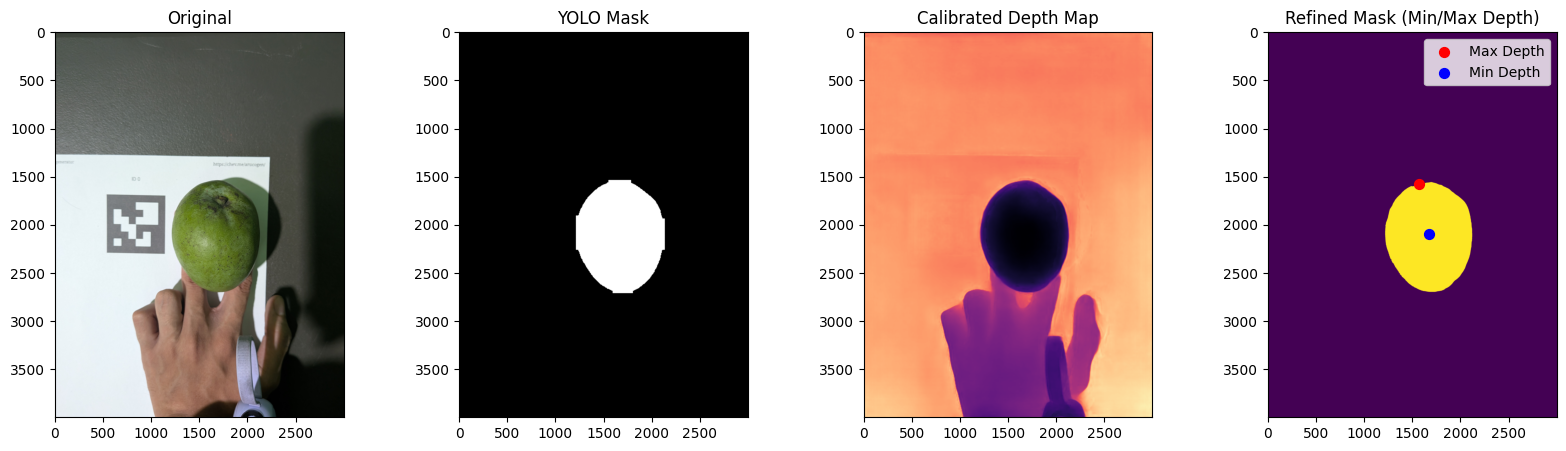

est. height: 6.86 cm
est. width: 5.43 cm
est. thickness: 2.23 cm
est. sphericity: 63.64
est. volume_hull: 38.98 cm3
est. surface_area_hull: 37.46 cm2
est. ratio_lw: 1.26
est. ratio_tl: 0.33
est. ratio_tw: 0.41
est. solidity_3d: 46.92 %
mean_curvature: 0.00008
curvature_dev: 0.00014
distance_z: 0.11221 m
color_a: 110.78
color_b: 159.33
mango_w_metric_aruco: 7.29 cm
mango_h_metric_aruco: 9.21 cm


In [5]:
test_image = 'images/train/mango45_bac_u.jpg'
features = extract_mango_features(test_image, INTRINSICS, seg_model, depth_model, 1, 1)

# test_image = 'images/train/mango36_bot_r.jpg'
# features = extract_mango_features(test_image, INTRINSICS, seg_model, depth_model, 0, 1)


#### BATCH (RUN ONCE)


In [ ]:
def batch_process_mangoes(image_folder, output_csv, intrinsics, y_features_path):
    """
    Iterates through a folder, filters to only include images with ArUco markers,
    extracts features, and saves them to a CSV.
    """
    df_y = pd.read_csv(y_features_path)
    aruco_filenames = set(df_y[df_y['has_aruco'] == 1]['filename'].tolist())
    
    all_features = []
    print(f"Found {len(aruco_filenames)} images with ArUco. Starting extraction...")

    for filename in tqdm(os.listdir(image_folder)):
        if filename not in aruco_filenames:
            continue
            
        img_path = os.path.join(image_folder, filename)
        try:
            features = extract_mango_features(img_path, intrinsics, seg_model, depth_model, 0, 0)
            if features is None:
                print(f"Warning: feature extraction returned None for {filename}")
                continue
            features['filename'] = filename
            all_features.append(features)
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue

    df = pd.DataFrame(all_features)
    cols = ['filename'] + [c for c in df.columns if c != 'filename']
    df = df[cols]

    df.to_csv(output_csv, index=False)
    print(f"Feature extraction complete! Saved to: {output_csv}")
    return df

batch_process_mangoes(TRAIN_IMAGE_DIR, MANGO_X_FEATURES_PATH, INTRINSICS, MANGO_Y_FEATURES_PATH)


#### EVEN MORE FEATURES

In [6]:
def engineer_features(df):
    df = df.copy()
    
    # 1. Bounding box volume estimate
    df['vol_bbox'] = df['width'] * df['height'] * df['thickness']
    
    # 2. Ellipsoidal volume estimate
    df['vol_ellipsoid'] = (np.pi / 6) * df['width'] * df['height'] * df['thickness']
    
    # 3. Volumetric to surface area ratio
    df['vol_sa_ratio'] = df['volume_hull'] / df['surface_area_hull'] if 'surface_area_hull' in df.columns else 0.0
    
    # 4. Dimension ratios
    df['ratio_lw'] = df['length'] / df['width'] if 'length' in df.columns else (df['height'] / df['width'])
    df['ratio_tl'] = df['thickness'] / df['length'] if 'length' in df.columns else (df['thickness'] / df['height'])
    df['ratio_tw'] = df['thickness'] / df['width']
    
    # 5. Color difference (Yellowing indicator: b - a)
    df['color_diff_ba'] = df['color_b'] - df['color_a']
    
    # 6. Color magnitude
    df['color_magnitude'] = np.sqrt(df['color_a']**2 + df['color_b']**2)
    
    # 7. 2D Bounding Box Aspect Ratio
    df['bbox_ratio'] = df['bbox_h_px'] / df['bbox_w_px']
    
    # ArUco specific features
    if 'mango_area_px' in df.columns:
        df['solidity_2d'] = df['mango_area_px'] / (df['bbox_w_px'] * df['bbox_h_px'])
        df['bbox_area_metric_aruco'] = df['mango_w_metric_aruco'] * df['mango_h_metric_aruco']
        df['solidity_2d_metric'] = df['mango_area_metric_aruco'] / df['bbox_area_metric_aruco']
        
    # Depth-normalized / Pseudo-metric features
    if 'distance_z' in df.columns:
        z = df['distance_z']
        fx, fy = 2123.0, 2123.0
        df['width_angular'] = df['bbox_w_px'] / fx
        df['height_angular'] = df['bbox_h_px'] / fy
        df['width_pseudo_m'] = df['bbox_w_px'] * z / fx
        df['height_pseudo_m'] = df['bbox_h_px'] * z / fy
        df['vol_pseudo_m'] = df['width_pseudo_m'] * df['height_pseudo_m'] * z
        df['depth_inv'] = 1.0 / z
        df['width_per_depth'] = df['width'] / z
        df['height_per_depth'] = df['height'] / z
        df['thick_per_depth'] = df['thickness'] / z
        df['vol_norm_depth3'] = df['volume_hull'] / (z ** 3)
        
    # Group A/B/C derived features
    if 'ellipse_major_px' in df.columns:
        df['ellipse_area_px'] = np.pi * (df['ellipse_major_px']/2) * (df['ellipse_minor_px']/2)
        if 'distance_z' in df.columns:
            z = df['distance_z']
            fx, fy = 2123.0, 2123.0
            # Depth-normalized mask area estimate
            df['mask_area_depth_norm'] = df['mask_area_px'] * (z ** 2) / (fx * fy)
            # Volumetric estimate using fitted ellipse major/minor axes mapped to metric space
            m_ellipse_major = df['ellipse_major_px'] * z / fy
            m_ellipse_minor = df['ellipse_minor_px'] * z / fx
            df['vol_ellipse_metric'] = (np.pi / 6) * m_ellipse_major * (m_ellipse_minor ** 2)
            
    if 'depth_range' in df.columns:
        # Relative depth variability (IQR normalized by range)
        df['depth_rel_iqr'] = df['depth_iqr'] / (df['depth_range'] + 1e-5)
        
    if 'color_std_a' in df.columns:
        # Illumination-robust chromaticity variation ratio
        df['chroma_var_ratio'] = df['color_std_a'] / (df['color_std_b'] + 1e-5)

    return df


### ORIENTATION MODEL


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import json

def train_orientation_model_cnn(x_csv_path, y_csv_path):
    save_dir = "models/orientation"
    os.makedirs(save_dir, exist_ok=True)
    
    # Load pre-trained CNN weights if available to save notebook runtime
    model_path = os.path.join(save_dir, 'orientation_cnn.pth')
    mapping_path = os.path.join(save_dir, 'class_mapping.json')
    
    classes = ['back', 'bottom', 'front', 'side', 'top']
    model = models.mobilenet_v3_small()
    num_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(num_features, len(classes))
    
    if os.path.exists(model_path) and os.path.exists(mapping_path):
        print(f"Loading existing unified CNN model from {model_path}...")
        model.load_state_dict(torch.load(model_path, map_location='cpu'))
        model.eval()
        with open(mapping_path, 'r') as f:
            loaded_classes = json.load(f)
        return model, loaded_classes
    else:
        print(f"Pre-trained model not found. Please run models/orientation/train_orientation_cnn.py to train the CNN.")
        return None, classes

orientation_cnn_model, class_mapping = train_orientation_model_cnn(MANGO_X_FEATURES_PATH, MANGO_Y_FEATURES_PATH)

# ---- Evaluate the CNN orientation model on the held-out test set ----
if orientation_cnn_model is not None:
    import numpy as np
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    CLASS_TO_IDX = {c: i for i, c in enumerate(class_mapping)}

    # Load ground-truth labels (ArUco subset)
    df_y_eval = pd.read_csv(MANGO_Y_FEATURES_PATH)
    df_y_eval = df_y_eval[df_y_eval['has_aruco'] == 1].reset_index(drop=True)

    # Pre-process crops using the YOLO segmentation mask (same pipeline as training)
    print("Pre-processing images for CNN evaluation (this may take a minute)...")
    eval_crops, eval_labels, eval_mango_ids = [], [], []
    for _, row in df_y_eval.iterrows():
        fn = row['filename']
        orient = row['orientation']
        mango_id = row['mango_id']
        img_path = os.path.join(TRAIN_IMAGE_DIR, fn)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        results = seg_model(img_rgb, verbose=False)[0]
        if len(results.boxes) > 0 and results.masks is not None:
            msk = results.masks.data[0].cpu().numpy()
            msk = cv2.resize(msk, (w, h))
            v_idx, u_idx = np.where(msk > 0)
            if len(v_idx) > 0:
                y1, y2 = int(np.min(v_idx)), int(np.max(v_idx))
                x1, x2 = int(np.min(u_idx)), int(np.max(u_idx))
                pad_x = int((x2 - x1) * 0.05)
                pad_y = int((y2 - y1) * 0.05)
                x1, x2 = max(0, x1 - pad_x), min(w, x2 + pad_x)
                y1, y2 = max(0, y1 - pad_y), min(h, y2 + pad_y)
                crop = img_rgb[y1:y2, x1:x2]
            else:
                crop = img_rgb
        else:
            crop = img_rgb
        eval_crops.append(cv2.resize(crop, (224, 224)))
        eval_labels.append(CLASS_TO_IDX[orient])
        eval_mango_ids.append(mango_id)

    df_eval = pd.DataFrame({'crop': eval_crops, 'label': eval_labels, 'mango_id': eval_mango_ids})

    # Group-based split — mirrors models/orientation/train_orientation_cnn.py exactly
    gss_eval = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    _, test_idx = next(gss_eval.split(df_eval, df_eval['label'], groups=df_eval['mango_id']))
    df_test_eval = df_eval.iloc[test_idx].reset_index(drop=True)
    print(f"Evaluation test size: {len(df_test_eval)} images from unseen mango subjects")

    # Run inference on test set
    cnn_eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    all_preds_eval, all_targets_eval = [], []
    orientation_cnn_model.eval()
    with torch.no_grad():
        for _, row in df_test_eval.iterrows():
            img_pil = Image.fromarray(row['crop'])
            input_tensor = cnn_eval_transform(img_pil).unsqueeze(0)
            outputs = orientation_cnn_model(input_tensor)
            _, predicted_idx = outputs.max(1)
            all_preds_eval.append(predicted_idx.item())
            all_targets_eval.append(row['label'])

    all_preds_eval = np.array(all_preds_eval)
    all_targets_eval = np.array(all_targets_eval)

    acc_eval = accuracy_score(all_targets_eval, all_preds_eval)
    print(f"\n--- CNN Orientation Model Evaluation (ArUco subset) ---")
    print(f"Overall Accuracy: {acc_eval:.2%}")
    print("\nDetailed Classification Report:")
    print(classification_report(all_targets_eval, all_preds_eval, target_names=class_mapping))

    # Plot and save confusion matrix
    save_dir_eval = "models/orientation"
    os.makedirs(save_dir_eval, exist_ok=True)
    plt.figure(figsize=(8, 6))
    cm_eval = confusion_matrix(all_targets_eval, all_preds_eval)
    sns.heatmap(cm_eval, annot=True, fmt='d',
                xticklabels=class_mapping, yticklabels=class_mapping, cmap='Oranges')
    plt.title("CNN Orientation Confusion Matrix (ArUco Subset)")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    cm_path_eval = os.path.join(save_dir_eval, 'orientation_confusion_matrix_cnn.png')
    plt.savefig(cm_path_eval, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to: {cm_path_eval}")
else:
    print("Skipping evaluation: CNN model not loaded.")


In [8]:
def predict_orientation(features_dict, clf=None):
    # Extract image path from features dict
    image_path = features_dict.get('image_path')
    if not image_path or not os.path.exists(image_path):
        # Fallback to a default/placeholder orientation if path is missing
        return 'side'
        
    # 1. Load image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    # 2. Segment using global seg_model to find the crop
    results = seg_model(img_rgb, verbose=False)[0]
    if len(results.boxes) > 0 and results.masks is not None:
        mask = results.masks[0].data[0].cpu().numpy()
        mask = cv2.resize(mask, (w, h))
        v, u = np.where(mask > 0)
        y1, y2 = np.min(v), np.max(v)
        x1, x2 = np.min(u), np.max(u)
        pad_x = int((x2 - x1) * 0.05)
        pad_y = int((y2 - y1) * 0.05)
        x1 = max(0, x1 - pad_x)
        x2 = min(w, x2 + pad_x)
        y1 = max(0, y1 - pad_y)
        y2 = min(h, y2 + pad_y)
        crop = img_rgb[y1:y2, x1:x2]
    else:
        crop = img_rgb
        
    # 3. Resize and preprocess
    crop_resized = cv2.resize(crop, (224, 224))
    crop_pil = Image.fromarray(crop_resized)
    
    cnn_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = cnn_transform(crop_pil).unsqueeze(0)
    
    # 4. Predict using the global cnn model
    with torch.no_grad():
        outputs = orientation_cnn_model(input_tensor)
        _, predicted_idx = outputs.max(1)
        predicted_orient = class_mapping[predicted_idx.item()]
        
    return predicted_orient

test_image = 'images/train/mango36_sia_r.jpg'
features = extract_mango_features(test_image, INTRINSICS, seg_model, depth_model, 0, 0)
orientation = predict_orientation(features)
print(f"orientation: {orientation}")


orientation: side


### TRAIN MANGO MORPHOLOGY (EXTERNAL) AND RIPENESS MODELS FROM EXTRACTED FEATURES PER ORIENTATION


In [34]:
def train_orientation_specialist(features_csv, ground_truth_csv, view_name):
    # Setup Folders
    morph_dir = f"models/aruco/morphology_external/{view_name}"
    ripe_dir = f"models/aruco/ripeness/{view_name}"
    os.makedirs(morph_dir, exist_ok=True)
    os.makedirs(ripe_dir, exist_ok=True)

    # Load and Merge Data
    try:
        df_x = pd.read_csv(features_csv)
        df_x = engineer_features(df_x)
        df_y = pd.read_csv(ground_truth_csv)
        df = pd.merge(df_x, df_y, on='filename')
    except Exception as e:
        print(f"Error loading data: {e}")
        return None, None
    
    # Filter by orientation
    view_df = df[df['orientation'] == view_name].copy()
    
    if len(view_df) < 10:
        print(f"Skipping {view_name}: Insufficient data ({len(view_df)} samples).")
        return None, None

    # Optimal Features dictionary discovered via out-of-fold Group CV search
    OPTIMAL_FEATURES = {
        'morphology': {
            'side': ['mango_w_metric_aruco', 'mango_area_metric_aruco'],
            'top': ['mango_w_metric_aruco', 'mango_area_metric_aruco'],
            'bottom': ['mango_area_metric_aruco', 'mean_curvature', 'color_a', 'bbox_h_px'],
            'front': ['mango_h_metric_aruco', 'aruco_scale', 'curvature_dev', 'mango_area_metric_aruco', 'ellipse_major_px'],
            'back': ['mango_area_metric_aruco', 'mango_h_metric_aruco'],
        },
        'ripeness': {
            'side': ['color_hue_std', 'thickness', 'color_a', 'color_std_b', 'width'],
            'top': ['color_a'],
            'bottom': ['color_hue_mean'],
            'front': ['color_saturation'],
            'back': ['color_a'],
        },
    }

    # Features
    morph_features = OPTIMAL_FEATURES['morphology'].get(view_name, [])
    ripe_features = OPTIMAL_FEATURES['ripeness'].get(view_name, [])
    
    # --- STRATEGIC SEGREGATION OF TARGET METRICS ---
    linear_cols = ['m_height', 'm_width', 'm_thickness']
    volume_cols = ['m_volume']
    weight_cols = ['m_weight']
    all_external_targets = linear_cols + volume_cols + weight_cols

    X_morph = view_df[morph_features]
    X_ripe = view_df[ripe_features]
    y_morphology = view_df[all_external_targets]
    y_ripeness = view_df['is_ripe']
    groups = view_df['mango_id']

    # Two Separate Scalers
    scaler_morph = StandardScaler()
    X_m_scaled = pd.DataFrame(scaler_morph.fit_transform(X_morph), columns=morph_features)
    scaler_ripe = StandardScaler()
    X_r_scaled = pd.DataFrame(scaler_ripe.fit_transform(X_ripe), columns=ripe_features)

    # Independent Group Shuffle Splits (train on 80% mangos, validate on 20% unseen mangos to prevent identity leakage)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    
    train_m_idx, test_m_idx = next(gss.split(X_m_scaled, y_morphology, groups=groups))
    X_m_train, X_m_test = X_m_scaled.iloc[train_m_idx], X_m_scaled.iloc[test_m_idx]
    y_m_train, y_m_test = y_morphology.iloc[train_m_idx], y_morphology.iloc[test_m_idx]
    
    train_r_idx, test_r_idx = next(gss.split(X_r_scaled, y_ripeness, groups=groups))
    X_r_train, X_r_test = X_r_scaled.iloc[train_r_idx], X_r_scaled.iloc[test_r_idx]
    y_r_train, y_r_test = y_ripeness.iloc[train_r_idx], y_ripeness.iloc[test_r_idx]

    # --- Model A: Morphologist Estimator (External Multi-Group) ---
    morph_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, min_samples_leaf=1, max_features='sqrt', random_state=42, n_jobs=-1))
    morph_model.fit(X_m_train, y_m_train.values) # Using .values to pass clean numpy arrays
    
    # --- Model B: Ripeness Classifier ---
    ripe_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    ripe_model.fit(X_r_train, y_r_train)

    # --- EVALUATION WITH SEMANTIC GROUPING ---
    print(f"\n{'='*20}\nEVALUATION: {view_name.upper()} (EXTERNAL & RIPENESS)\n{'='*20}")
    
    # Structural Mapping alignment
    m_preds = morph_model.predict(X_m_test)
    preds_df = pd.DataFrame(m_preds, columns=all_external_targets, index=y_m_test.index)
    
    # Group A: Linear Dimensions (cm)
    r2_linear = r2_score(y_m_test[linear_cols], preds_df[linear_cols], multioutput='uniform_average')
    mae_linear = mean_absolute_error(y_m_test[linear_cols], preds_df[linear_cols])
    print(f"Linear Dimensions Group -> Mean R2: {r2_linear:.4f} | Mean MAE: {mae_linear:.4f} cm")
    
    # Group B: Volumetric Space (cm³)
    r2_volume = r2_score(y_m_test[volume_cols], preds_df[volume_cols])
    mae_volume = mean_absolute_error(y_m_test[volume_cols], preds_df[volume_cols])
    print(f"Volumetric Group Space  -> Mean R2: {r2_volume:.4f} | Mean MAE: {mae_volume:.4f} cm³")
    
    # Group C: Gravimetric Mass (grams)
    r2_weight = r2_score(y_m_test[weight_cols], preds_df[weight_cols])
    mae_weight = mean_absolute_error(y_m_test[weight_cols], preds_df[weight_cols])
    print(f"Gravimetric Mass Group  -> Mean R2: {r2_weight:.4f} | Mean MAE: {mae_weight:.4f} grams")
    
    # Ripeness Classification
    r_preds = ripe_model.predict(X_r_test)
    print("\nRipeness Classification Report:")
    print(classification_report(y_r_test, r_preds, zero_division=0))

    # --- VISUALIZATIONS ---
    # Morphology Feature Importance
    importances = [est.feature_importances_ for est in morph_model.estimators_]
    avg_importance = np.mean(importances, axis=0) 
    plt.figure(figsize=(10, 5))
    pd.Series(avg_importance, index=morph_features).sort_values().plot(kind='barh', color='teal')
    plt.title(f"External Morphological Feature Importance ({view_name})")
    plt.tight_layout()
    plt.savefig(f"{morph_dir}/feature_importance.png")
    plt.close()

    # Ripeness Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_r_test, r_preds), annot=True, fmt='d', cmap='YlOrBr', 
                xticklabels=['Unripe', 'Ripe'], yticklabels=['Unripe', 'Ripe'])
    plt.title(f"Ripeness Confusion Matrix ({view_name})")
    plt.tight_layout()
    plt.savefig(f"{ripe_dir}/ripeness_confusion_matrix.png")
    plt.close()
    
    # Ripeness Feature Importance
    plt.figure(figsize=(10, 5))
    pd.Series(ripe_model.feature_importances_, index=ripe_features).sort_values().plot(kind='barh', color='orange')
    plt.title(f"Ripeness Feature Importance ({view_name})")
    plt.tight_layout()
    plt.savefig(f"{ripe_dir}/ripeness_feature_importance.png")
    plt.close()

    # Save Models and Scalers
    joblib.dump(morph_model, f'{morph_dir}/morphology_model.joblib')
    joblib.dump(scaler_morph, f'{morph_dir}/scaler_morph.joblib')
    joblib.dump(ripe_model, f'{ripe_dir}/ripeness_model.joblib')
    joblib.dump(scaler_ripe, f'{ripe_dir}/scaler_ripe.joblib')
    
    # Save Feature configs as JSON for predict_mango_external
    import json
    with open(f'{morph_dir}/features.json', 'w') as f:
        json.dump(morph_features, f)
    with open(f'{ripe_dir}/features.json', 'w') as f:
        json.dump(ripe_features, f)
    
    return morph_model, ripe_model

views = ['side', 'top', 'bottom', 'front', 'back']
for view in views:
    train_orientation_specialist(MANGO_X_FEATURES_PATH, MANGO_Y_FEATURES_PATH, view)



EVALUATION: SIDE (EXTERNAL & RIPENESS)
Linear Dimensions Group -> Mean R2: 0.4417 | Mean MAE: 0.4228 cm
Volumetric Group Space  -> Mean R2: 0.8358 | Mean MAE: 16.1094 cm³
Gravimetric Mass Group  -> Mean R2: 0.8153 | Mean MAE: 16.8236 grams

Ripeness Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


EVALUATION: TOP (EXTERNAL & RIPENESS)
Linear Dimensions Group -> Mean R2: 0.5518 | Mean MAE: 0.3361 cm
Volumetric Group Space  -> Mean R2: 0.6883 | Mean MAE: 30.5792 cm³
Gravimetric Mass Group  -> Mean R2: 0.7806 | Mean MAE: 22.8484 grams

Ripeness Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1     

In [35]:
def predict_mango_external(features_dict, orientation):
    """
    Layer 1 Inference Pipeline:
    Maps raw image features to external mango dimensions and ripeness status.
    Returns a single dictionary containing all Layer 1 outputs.
    """
    # 1. Setup paths
    morph_l1_path = f'models/aruco/morphology_external/{orientation}/morphology_model.joblib'
    scaler_l1_path = f'models/aruco/morphology_external/{orientation}/scaler_morph.joblib'
    
    ripe_path = f'models/aruco/ripeness/{orientation}/ripeness_model.joblib'
    scaler_ripe_path = f'models/aruco/ripeness/{orientation}/scaler_ripe.joblib'

    # 2. Load models and scalers
    morph_l1_model = joblib.load(morph_l1_path)
    scaler_l1 = joblib.load(scaler_l1_path)
    ripe_model = joblib.load(ripe_path)
    scaler_ripe = joblib.load(scaler_ripe_path)
    
    # Load dynamic feature configurations matching training layout exactly
    import json
    with open(f'models/aruco/morphology_external/{orientation}/features.json', 'r') as f:
        morph_features = json.load(f)
    with open(f'models/aruco/ripeness/{orientation}/features.json', 'r') as f:
        ripe_features = json.load(f)
    
    # 3. Apply feature engineering then format inputs and scale
    features_df = engineer_features(pd.DataFrame([features_dict]))
    input_morph_df = features_df[morph_features]
    input_ripe_df = features_df[ripe_features]
    
    morph_l1_scaled = scaler_l1.transform(input_morph_df)
    ripe_scaled = scaler_ripe.transform(input_ripe_df)
    
    morph_l1_scaled_df = pd.DataFrame(morph_l1_scaled, columns=morph_features)
    ripe_scaled_df = pd.DataFrame(ripe_scaled, columns=ripe_features)
    
    # 4. Execute Layer 1 predictions
    external_preds = morph_l1_model.predict(morph_l1_scaled_df)[0]
    ripe_pred = ripe_model.predict(ripe_scaled_df)[0]
    
    # 5. Pack everything into a clean, single dictionary output
    layer1_results = {
        'm_height': external_preds[0],
        'm_width': external_preds[1],
        'm_thickness': external_preds[2],
        'm_volume': external_preds[3],
        'm_weight': external_preds[4],
        'is_ripe': ripe_pred
    }
    
    return layer1_results


### TRAIN MANGO MORPHOLOGY (INTERNAL) MODEL FROM EXTERNAL AND RIPENESS


In [36]:
def train_internal_seed_specialist(ground_truth_csv):
    """
    Layer 2 Regressor: Uses group-based splitting via mango_id to map 
    external mango dimensions to internal seed dimensions, using only the ArUco data subset.
    """
    seed_dir = "models/aruco/morphology_internal"
    os.makedirs(seed_dir, exist_ok=True)

    # 1. Load Ground Truth Data
    try:
        df = pd.read_csv(ground_truth_csv)
    except Exception as e:
        print(f"Error loading ground truth data: {e}")
        return None

    # Filter to only include ArUco data subset
    df = df[df['has_aruco'] == 1].copy()

    print(f"\n{'='*20}\nTRAINING LAYER 2: GLOBAL INTERNAL SEED MODEL (ARUCO ONLY)\n{'='*20}")

    # 2. Define Features, Grouping, and Categorized Targets
    layer2_features = ['m_height', 'm_width', 'm_thickness', 'm_volume', 'm_weight', 'is_ripe']
    
    linear_cols = ['b_height', 'b_width', 'b_thickness']
    volume_cols = ['b_volume']
    weight_cols = ['b_weight']
    all_internal_targets = linear_cols + volume_cols + weight_cols
    
    # Drop rows missing critical data elements
    df = df.dropna(subset=layer2_features + all_internal_targets + ['mango_id']).copy()

    X_layer2 = df[layer2_features].copy()
    y_layer2 = df[all_internal_targets]
    groups = df['mango_id']

    # 3. Preprocessing: Scale Numerical Input Features Only
    scaler_l2 = StandardScaler()
    numerical_features = ['m_height', 'm_width', 'm_thickness', 'm_volume', 'm_weight']
    X_layer2[numerical_features] = scaler_l2.fit_transform(X_layer2[numerical_features])

    # 4. Group-Based Split to Prevent Core Leakage across Identical Mangoes
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_layer2, y_layer2, groups=groups))

    X_train, X_test = X_layer2.iloc[train_idx], X_layer2.iloc[test_idx]
    y_test = y_layer2.iloc[test_idx]
    
    y_train_arr = y_layer2.iloc[train_idx].values

    # 5. Train Layer 2 Regressor
    seed_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    seed_model.fit(X_train, y_train_arr)

    # 6. Generate Predictions
    seed_preds = seed_model.predict(X_test)
    preds_df = pd.DataFrame(seed_preds, columns=all_internal_targets, index=y_test.index)

    # 7. Evaluation
    print(f"\n{'='*20}\nSEMANTIC GROUP EVALUATION\n{'='*20}")
    
    r2_linear = r2_score(y_test[linear_cols], preds_df[linear_cols], multioutput='uniform_average')
    mae_linear = mean_absolute_error(y_test[linear_cols], preds_df[linear_cols])
    print(f"Linear Dimensions Group (Seed) -> Mean R2: {r2_linear:.4f} | Mean MAE: {mae_linear:.4f} cm")
    
    r2_volume = r2_score(y_test[volume_cols], preds_df[volume_cols])
    mae_volume = mean_absolute_error(y_test[volume_cols], preds_df[volume_cols])
    print(f"Volumetric Group Space  (Seed) -> Mean R2: {r2_volume:.4f} | Mean MAE: {mae_volume:.4f} cm³")
    
    r2_weight = r2_score(y_test[weight_cols], preds_df[weight_cols])
    mae_weight = mean_absolute_error(y_test[weight_cols], preds_df[weight_cols])
    print(f"Gravimetric Mass Group  (Seed) -> Mean R2: {r2_weight:.4f} | Mean MAE: {mae_weight:.4f} grams")
    print(f"{'='*45}\n")

    # 8. Save Model Artifacts
    joblib.dump(seed_model, f'{seed_dir}/seed_model.joblib')
    joblib.dump(scaler_l2, f'{seed_dir}/scaler_l2.joblib')
    print(f"Layer 2 models safely preserved in: {seed_dir}/")
    
    # 9. Feature Importance Plot
    plt.figure(figsize=(10, 5))
    importances = np.mean([est.feature_importances_ for est in seed_model.estimators_], axis=0)
    pd.Series(importances, index=layer2_features).sort_values().plot(kind='barh', color='purple')
    plt.title("Layer 2: Structural Inputs to Seed Dimension Mapping")
    plt.tight_layout()
    plt.savefig(f"{seed_dir}/seed_feature_importance.png")
    plt.close()

    return seed_model

train_internal_seed_specialist(MANGO_Y_FEATURES_PATH)



TRAINING LAYER 2: GLOBAL INTERNAL SEED MODEL (ARUCO ONLY)

SEMANTIC GROUP EVALUATION
Linear Dimensions Group (Seed) -> Mean R2: 0.5999 | Mean MAE: 0.1820 cm
Volumetric Group Space  (Seed) -> Mean R2: 0.9417 | Mean MAE: 1.8000 cm³
Gravimetric Mass Group  (Seed) -> Mean R2: 0.9077 | Mean MAE: 1.9187 grams

Layer 2 models safely preserved in: models/aruco/morphology_internal/


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least

In [37]:
def predict_mango_internal(layer1_output_dict):
    """
    Layer 2 Inference Pipeline:
    Takes a single dictionary variable directly outputted by Layer 1,
    predicts the internal endocarp (seed bone) specifications, and 
    appends the seed predictions directly into the dictionary.
    """
    # 1. Setup paths
    seed_model_path = 'models/aruco/morphology_internal/seed_model.joblib'
    scaler_l2_path = 'models/aruco/morphology_internal/scaler_l2.joblib'
    
    if not os.path.exists(seed_model_path) or not os.path.exists(scaler_l2_path):
        raise FileNotFoundError("Layer 2 models not found. Run train_internal_seed_specialist() first.")

    # 2. Load models
    seed_model = joblib.load(seed_model_path)
    scaler_l2 = joblib.load(scaler_l2_path)
    
    # 3. Extract numerical features dynamically expected by the scaler
    l2_numerical_features = ['m_height', 'm_width', 'm_thickness', 'm_volume', 'm_weight']
    if hasattr(scaler_l2, 'feature_names_in_'):
        expected_numerical = list(scaler_l2.feature_names_in_)
    else:
        expected_numerical = l2_numerical_features
        
    # Build raw row array out of the dict parameters
    raw_numerical_data = [[layer1_output_dict[col] for col in expected_numerical]]
    
    # 4. Apply Scaling
    input_numerical_df = pd.DataFrame(raw_numerical_data, columns=expected_numerical)
    scaled_numerical = scaler_l2.transform(input_numerical_df)
    
    # 5. Build final tracking DataFrame (wrapping text label)
    input_l2_df = pd.DataFrame(scaled_numerical, columns=expected_numerical)
    if hasattr(seed_model, 'feature_names_in_') and 'is_ripe' in seed_model.feature_names_in_:
        input_l2_df['is_ripe'] = int(layer1_output_dict['is_ripe'])
        # Reorder columns to match the model's expected feature names order
        input_l2_df = input_l2_df[list(seed_model.feature_names_in_)]
    else:
        input_l2_df['is_ripe'] = int(layer1_output_dict['is_ripe'])

    # 6. Execute Layer 2 prediction
    internal_preds = seed_model.predict(input_l2_df)[0]

    # 7. MUTATE AND UPDATE THE SINGLE DICTIONARY DIRECTLY
    layer1_output_dict.update({
        'b_height': internal_preds[0],
        'b_width': internal_preds[1],
        'b_thickness': internal_preds[2],
        'b_volume': internal_preds[3],
        'b_weight': internal_preds[4]
    })
    
    return layer1_output_dict


### ESTIMATE MORPHOLOGY AND RIPENESS


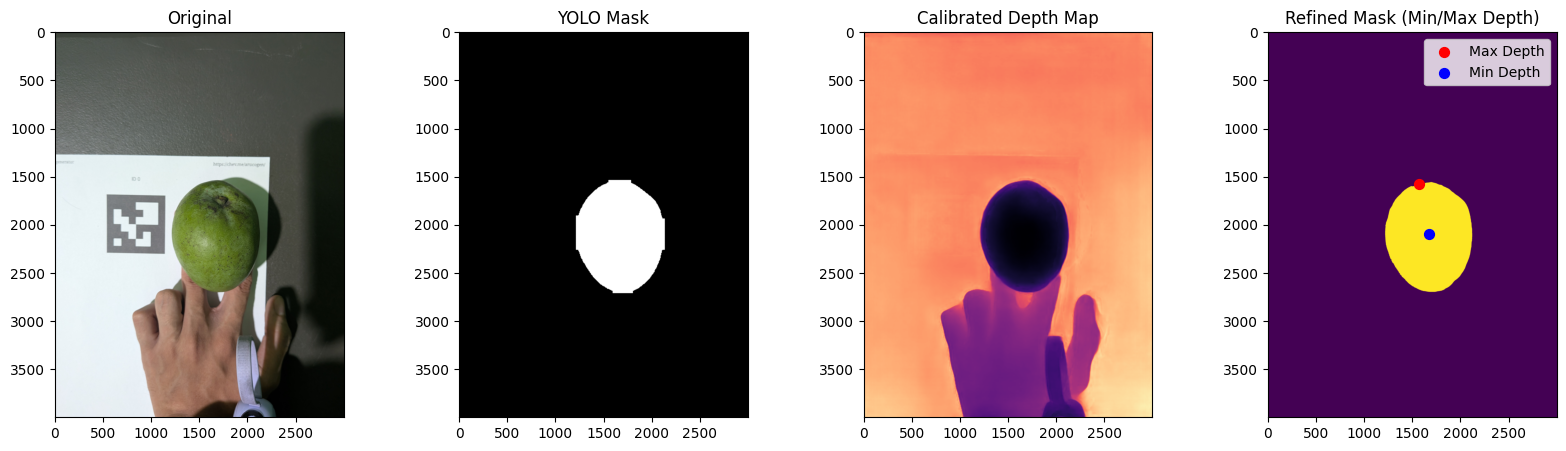


       MANGO ANALYSIS PROFILE REPORT       
 Physiological Maturity :  [ UNRIPE ]
----------------------------------------
 EXTERNAL METRICS (Whole Mango)
  • Dimensions : 7.91 H x 6.42 W x 5.95 T (cm)
  • Volume     : 180.10 cm³
  • Mass/Weight: 176.55 grams
----------------------------------------
 INTERNAL METRICS (Mango Bone)
  • Dimensions : 5.90 H x 3.61 W x 2.00 T (cm)
  • Volume     : 25.00 cm³
  • Mass/Weight: 25.00 grams



In [38]:
def print_mango_report(output_dict):
    """
    Cleans up NumPy data types and formats the final prediction dictionary
    into an organized, readable terminal report for your thesis data logs.
    """
    print(f"\n{'='*40}")
    print(f"       MANGO ANALYSIS PROFILE REPORT       ")
    print(f"{'='*40}")
    
    ripe_val = output_dict.get('is_ripe', 0)
    if isinstance(ripe_val, (int, np.integer)):
        ripeness_status = "Ripe" if ripe_val == 1 else "Unripe"
    else:
        ripeness_status = str(ripe_val)
        
    print(f" Physiological Maturity :  [ {ripeness_status.upper()} ]")
    print(f"{'-'*40}")
    
    print(" EXTERNAL METRICS (Whole Mango)")
    print(f"  • Dimensions : {output_dict['m_height']:.2f} H x {output_dict['m_width']:.2f} W x {output_dict['m_thickness']:.2f} T (cm)")
    print(f"  • Volume     : {output_dict['m_volume']:.2f} cm³")
    print(f"  • Mass/Weight: {output_dict['m_weight']:.2f} grams")
    print(f"{'-'*40}")
    
    print(" INTERNAL METRICS (Mango Bone)")
    print(f"  • Dimensions : {output_dict['b_height']:.2f} H x {output_dict['b_width']:.2f} W x {output_dict['b_thickness']:.2f} T (cm)")
    print(f"  • Volume     : {output_dict['b_volume']:.2f} cm³")
    print(f"  • Mass/Weight: {output_dict['b_weight']:.2f} grams")
    print(f"{'='*40}\n")

test_image = 'images/train/mango45_bac_u.jpg'
features = extract_mango_features(test_image, INTRINSICS, seg_model, depth_model, 1, 0)
orientation = predict_orientation(features, orientation_clf)
output = predict_mango_external(features, orientation)
output = predict_mango_internal(output)
print_mango_report(output)
